# Tools

## How to

### 1. Write a tool function

* Plain python function that will be executed when Claude decides it needs some additional information to help the user

**Best practices:**

* Use well-named, descriptive arguments
* Validate the inputs, raising an error if they fail validation
* Return meaningful errors - Claude will try to call to use your function a second time (**Claude might retry**)

e.g.

```python
import requests

def get_weather(location):
    if not location or location.strip() == "":
        raise ValueError("Location cannot be empty")

    url = "https://fakeweatherapi.example.com/current"
    params = {
        "q": location,
        "appid": api_key,
        "units": "metric"
    }

    # Execute the GET request
    response = requests.get(url, params=params, timeout=10)
    
    # Raise an exception for HTTP error codes (4xx or 5xx)
    response.raise_for_status()

    return response.json()
```


### 2. Write a JSON schema

**Write a JSON schema spec to describe your function**

* The JSON Schema helps Claude understand what arguments your function requires

**Best practices:**

*  Explain what the tool does, when to use it and what it returns
*  Aim for 3-4 sentences
*  Provide SUPER detailed descriptions

e.g. 

```json

{
  "name": "get_weather",
  "description": "Retrieves current weather ... ",
  "input_schema": {
    "type": "object",
    "properties": {
      "location": {
        "type": "string",
        "description": "The location for which ... "
      }
    },
    "required": [
      "location"
    ]
  }
}

```

### 3. Call Claude with JSON schema

### 4. Run tool

### 5. Add Tool Results and call Claude again


## Boilerplate code (already given by lesson)

In [3]:
# Load env variables and create client
from dotenv import load_dotenv
from anthropic import Anthropic

load_dotenv()

client = Anthropic()
model = "claude-haiku-4-5"

In [4]:
# Helper functions
def add_user_message(messages, text):
    user_message = {"role": "user", "content": text}
    messages.append(user_message)


def add_assistant_message(messages, text):
    assistant_message = {"role": "assistant", "content": text}
    messages.append(assistant_message)


def chat(messages, system=None, temperature=1.0, stop_sequences=[]):
    params = {
        "model": model,
        "max_tokens": 1000,
        "messages": messages,
        "temperature": temperature,
        "stop_sequences": stop_sequences,
    }

    if system:
        params["system"] = system

    message = client.messages.create(**params)
    return message.content[0].text

In [49]:
# Tools and Schemas

from datetime import datetime, timedelta


def add_duration_to_datetime(
    datetime_str, duration=0, unit="days", input_format="%Y-%m-%d"
):
    date = datetime.strptime(datetime_str, input_format)

    if unit == "seconds":
        new_date = date + timedelta(seconds=duration)
    elif unit == "minutes":
        new_date = date + timedelta(minutes=duration)
    elif unit == "hours":
        new_date = date + timedelta(hours=duration)
    elif unit == "days":
        new_date = date + timedelta(days=duration)
    elif unit == "weeks":
        new_date = date + timedelta(weeks=duration)
    elif unit == "months":
        month = date.month + duration
        year = date.year + month // 12
        month = month % 12
        if month == 0:
            month = 12
            year -= 1
        day = min(
            date.day,
            [
                31,
                29 if year % 4 == 0 and (year % 100 != 0 or year % 400 == 0) else 28,
                31,
                30,
                31,
                30,
                31,
                31,
                30,
                31,
                30,
                31,
            ][month - 1],
        )
        new_date = date.replace(year=year, month=month, day=day)
    elif unit == "years":
        new_date = date.replace(year=date.year + duration)
    else:
        raise ValueError(f"Unsupported time unit: {unit}")

    return new_date.strftime("%A, %B %d, %Y %I:%M:%S %p")


def set_reminder(content, timestamp):
    print(f"----\nSetting the following reminder for {timestamp}:\n{content}\n----")


add_duration_to_datetime_schema = {
    "name": "add_duration_to_datetime",
    "description": "Adds a specified duration to a datetime string and returns the resulting datetime in a detailed format. This tool converts an input datetime string to a Python datetime object, adds the specified duration in the requested unit, and returns a formatted string of the resulting datetime. It handles various time units including seconds, minutes, hours, days, weeks, months, and years, with special handling for month and year calculations to account for varying month lengths and leap years. The output is always returned in a detailed format that includes the day of the week, month name, day, year, and time with AM/PM indicator (e.g., 'Thursday, April 03, 2025 10:30:00 AM').",
    "input_schema": {
        "type": "object",
        "properties": {
            "datetime_str": {
                "type": "string",
                "description": "The input datetime string to which the duration will be added. This should be formatted according to the input_format parameter.",
            },
            "duration": {
                "type": "number",
                "description": "The amount of time to add to the datetime. Can be positive (for future dates) or negative (for past dates). Defaults to 0.",
            },
            "unit": {
                "type": "string",
                "description": "The unit of time for the duration. Must be one of: 'seconds', 'minutes', 'hours', 'days', 'weeks', 'months', or 'years'. Defaults to 'days'.",
            },
            "input_format": {
                "type": "string",
                "description": "The format string for parsing the input datetime_str, using Python's strptime format codes. For example, '%Y-%m-%d' for ISO format dates like '2025-04-03'. Defaults to '%Y-%m-%d'.",
            },
        },
        "required": ["datetime_str"],
    },
}

set_reminder_schema = {
    "name": "set_reminder",
    "description": "Creates a timed reminder that will notify the user at the specified time with the provided content. This tool schedules a notification to be delivered to the user at the exact timestamp provided. It should be used when a user wants to be reminded about something specific at a future point in time. The reminder system will store the content and timestamp, then trigger a notification through the user's preferred notification channels (mobile alerts, email, etc.) when the specified time arrives. Reminders are persisted even if the application is closed or the device is restarted. Users can rely on this function for important time-sensitive notifications such as meetings, tasks, medication schedules, or any other time-bound activities.",
    "input_schema": {
        "type": "object",
        "properties": {
            "content": {
                "type": "string",
                "description": "The message text that will be displayed in the reminder notification. This should contain the specific information the user wants to be reminded about, such as 'Take medication', 'Join video call with team', or 'Pay utility bills'.",
            },
            "timestamp": {
                "type": "string",
                "description": "The exact date and time when the reminder should be triggered, formatted as an ISO 8601 timestamp (YYYY-MM-DDTHH:MM:SS) or a Unix timestamp. The system handles all timezone processing internally, ensuring reminders are triggered at the correct time regardless of where the user is located. Users can simply specify the desired time without worrying about timezone configurations.",
            },
        },
        "required": ["content", "timestamp"],
    },
}

batch_tool_schema = {
    "name": "batch_tool",
    "description": "Invoke multiple other tool calls simultaneously",
    "input_schema": {
        "type": "object",
        "properties": {
            "invocations": {
                "type": "array",
                "description": "The tool calls to invoke",
                "items": {
                    "type": "object",
                    "properties": {
                        "name": {
                            "type": "string",
                            "description": "The name of the tool to invoke",
                        },
                        "arguments": {
                            "type": "string",
                            "description": "The arguments to the tool, encoded as a JSON string",
                        },
                    },
                    "required": ["name", "arguments"],
                },
            }
        },
        "required": ["invocations"],
    },
}

pass

## Tool definition

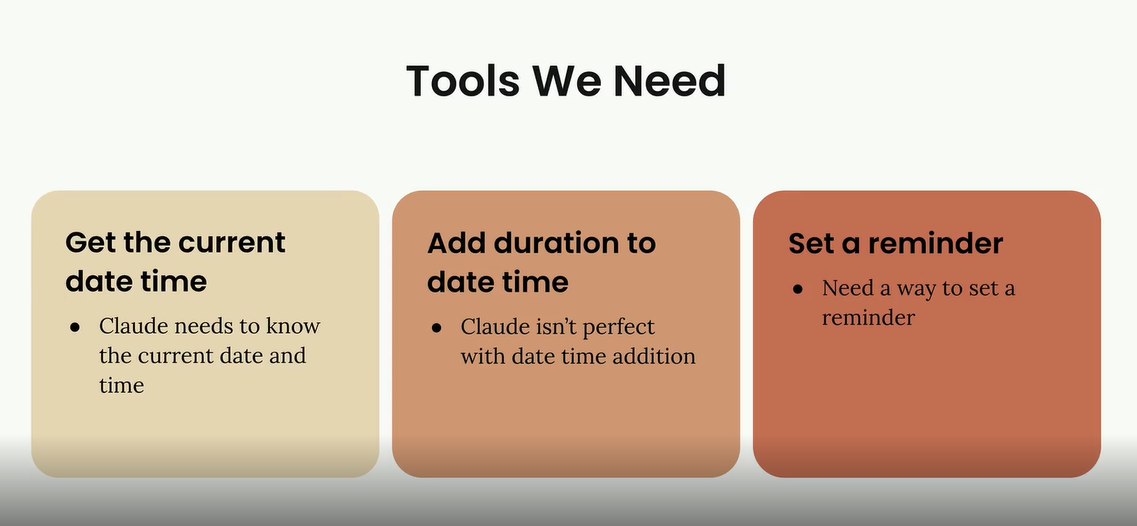

In [11]:
# Tool nº 1: Get current date time
def get_current_datetime(date_format="%Y-%m-%d %H:%M:%S"):
    if not date_format:
        raise ValueError("data_format cannot be empty")
    return datetime.now().strftime(date_format)

# Test
get_current_datetime()

'2026-04-16 11:48:40'

## To write JSON schema, simply ask to Claude (in chat UI) to create the JSON spec

* Add this as context: https://platform.claude.com/docs/en/agents-and-tools/tool-use/define-tools#best-practices-for-tool-definitions

In [13]:
from anthropic.types import ToolParam # Will prevent any type errors

In [14]:
get_current_datetime_schema = ToolParam({
  "name": "get_current_datetime",
  "description": "Returns the current local date and time as a formatted string. The format must be a valid Python strftime format string (e.g. '%Y-%m-%d %H:%M:%S'). It should be used when the user asks for the current date, time, or both. It will not return timezone information or parse/convert existing datetime strings.",
  "input_schema": {
    "type": "object",
    "properties": {
      "date_format": {
        "type": "string",
        "description": "A Python strftime format string controlling the output layout, e.g. '%Y-%m-%d %H:%M:%S' for '2025-04-16 13:45:00'. Defaults to '%Y-%m-%d %H:%M:%S' if not provided. Must not be empty."
      }
    },
    "required": []
  }
})

## Call Claude with JSON schema

In [21]:
messages = []

messages.append(
    {
        "role":"user",
        "content": "Hello there! how is it going?what is the exact time, formatted as HH:MM:SS?"
    }
)

response = client.messages.create(
    model = model,
    max_tokens = 1000,
    messages = messages,
    tools = [get_current_datetime_schema] # json schema specs of tools available
)

messages.append({
    "role":"assistant",
    "content": response.content 
})

messages



[{'role': 'user',
  'content': 'Hello there! how is it going?what is the exact time, formatted as HH:MM:SS?'},
 {'role': 'assistant',
  'content': [TextBlock(citations=None, text="Hello! It's going great, thanks for asking! Let me get the current time for you.", type='text'),
   ToolUseBlock(id='toolu_0144y6xWrtJLbJRyuE4VCxRa', caller=DirectCaller(type='direct'), input={'date_format': '%H:%M:%S'}, name='get_current_datetime', type='tool_use')]}]

> Por algún motivo no tenemos TextBlock (en el training salen ambos: TextBlock y ToolUseBlock)

Message(id='msg_014NGyJPnxBMZCmuxCe24cwT', container=None, content=[**ToolUseBlock(id='toolu_01Po3qKjs5zbfBNFde1LNgRZ', caller=DirectCaller(type='direct'), input={'date_format': '%H:%M:%S'}, name='get_current_datetime', type='tool_use')**], model='claude-haiku-4-5-20251001', role='assistant', stop_details=None, stop_reason='tool_use', stop_sequence=None, type='message', usage=Usage(cache_creation=CacheCreation(ephemeral_1h_input_tokens=0, ephemeral_5m_input_tokens=0), cache_creation_input_tokens=0, cache_read_input_tokens=0, inference_geo='not_available', input_tokens=713, output_tokens=63, server_tool_use=None, service_tier='standard'))

In [26]:
print(response.content) # can contain ToolUseBlock, TextBlock blocks

[TextBlock(citations=None, text="Hello! It's going great, thanks for asking! Let me get the current time for you.", type='text'), ToolUseBlock(id='toolu_0144y6xWrtJLbJRyuE4VCxRa', caller=DirectCaller(type='direct'), input={'date_format': '%H:%M:%S'}, name='get_current_datetime', type='tool_use')]


## Run Tool and Send Tool results

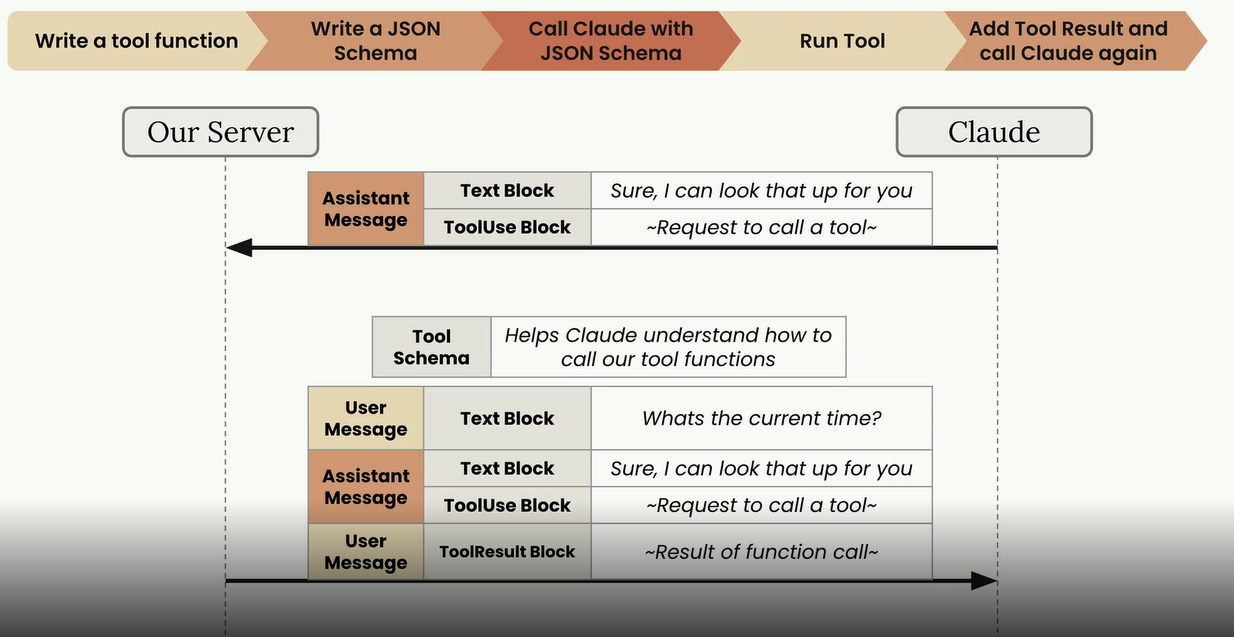

In [29]:
get_current_datetime(**response.content[1].input)

'12:16:10'

**Es el USER quien ejecuta el tool y manda el resultado**

We'll use the `ToolResult` block:

* Placed in the 'content' list of a user message
* Communicates the results of running a tool function back to Claude
* "tool_use_id" - Must match the id of the ToolUse block that this ToolResult corresponds to
* "content" - Output from running your tool, serialized as a string
* "is_error" - True if an error occurred

`tool_use_id` is fetched from Claude's `ToolUseBlock` id

`ToolUseBlock(id='toolu_0144y6xWrtJLbJRyuE4VCxRa', caller=DirectCaller(type='direct'), input={'date_format': '%H:%M:%S'}, name='get_current_datetime', type='tool_use')]`

Inside `ToolUseBlock` there can be several ids, be careful, they must be correctly matched/mapped

```json
{
  "tool_use_id": "toolu_01BEbi7q7qz",
  "type": "tool_result",
  "content": "12:47:13",
  "is_error": false
}
```

In [32]:
result = get_current_datetime(**response.content[1].input)

In [33]:
messages.append({
    "role":"user", # Es el user quien ejecuta el tool y envía el resultado
    "content": [
    {
        "type":"tool_result",
        "tool_use_id": response.content[1].id,
        "content": result,
        "is_error": False
    }
    ]
})

messages

[{'role': 'user',
  'content': 'Hello there! how is it going?what is the exact time, formatted as HH:MM:SS?'},
 {'role': 'assistant',
  'content': [TextBlock(citations=None, text="Hello! It's going great, thanks for asking! Let me get the current time for you.", type='text'),
   ToolUseBlock(id='toolu_0144y6xWrtJLbJRyuE4VCxRa', caller=DirectCaller(type='direct'), input={'date_format': '%H:%M:%S'}, name='get_current_datetime', type='tool_use')]},
 {'role': 'user',
  'content': [{'type': 'tool_result',
    'tool_use_id': 'toolu_0144y6xWrtJLbJRyuE4VCxRa',
    'content': '12:24:04',
    'is_error': False}]}]

In [34]:
client.messages.create(
    model = model,
    max_tokens = 1000,
    messages = messages,
    tools = [get_current_datetime_schema] # we must include the tool schema here too
)

Message(id='msg_01BdgRHSYNnvMRXTJKAfU2W9', container=None, content=[TextBlock(citations=None, text="The exact time right now is **12:24:04** (HH:MM:SS format). Hope you're having a good day! 😊", type='text')], model='claude-haiku-4-5-20251001', role='assistant', stop_details=None, stop_reason='end_turn', stop_sequence=None, type='message', usage=Usage(cache_creation=CacheCreation(ephemeral_1h_input_tokens=0, ephemeral_5m_input_tokens=0), cache_creation_input_tokens=0, cache_read_input_tokens=0, inference_geo='not_available', input_tokens=821, output_tokens=36, server_tool_use=None, service_tier='standard'))

Finally Claude responds us with only a TextBlock (which contains the result of the tool call):

```
Message(id='msg_01BdgRHSYNnvMRXTJKAfU2W9', container=None, content=[TextBlock(citations=None, text="The exact time right now is **12:24:04** (HH:MM:SS format). Hope you're having a good day! 😊", type='text')], model='claude-haiku-4-5-20251001', role='assistant', stop_details=None, stop_reason='end_turn', stop_sequence=None, type='message', usage=Usage(cache_creation=CacheCreation(ephemeral_1h_input_tokens=0, ephemeral_5m_input_tokens=0), cache_creation_input_tokens=0, cache_read_input_tokens=0, inference_geo='not_available', input_tokens=821, output_tokens=36, server_tool_use=None, service_tier='standard'))

## Multi-Turn conversations with tools

When we add tool calling in our application, Claude might require using multiple tools

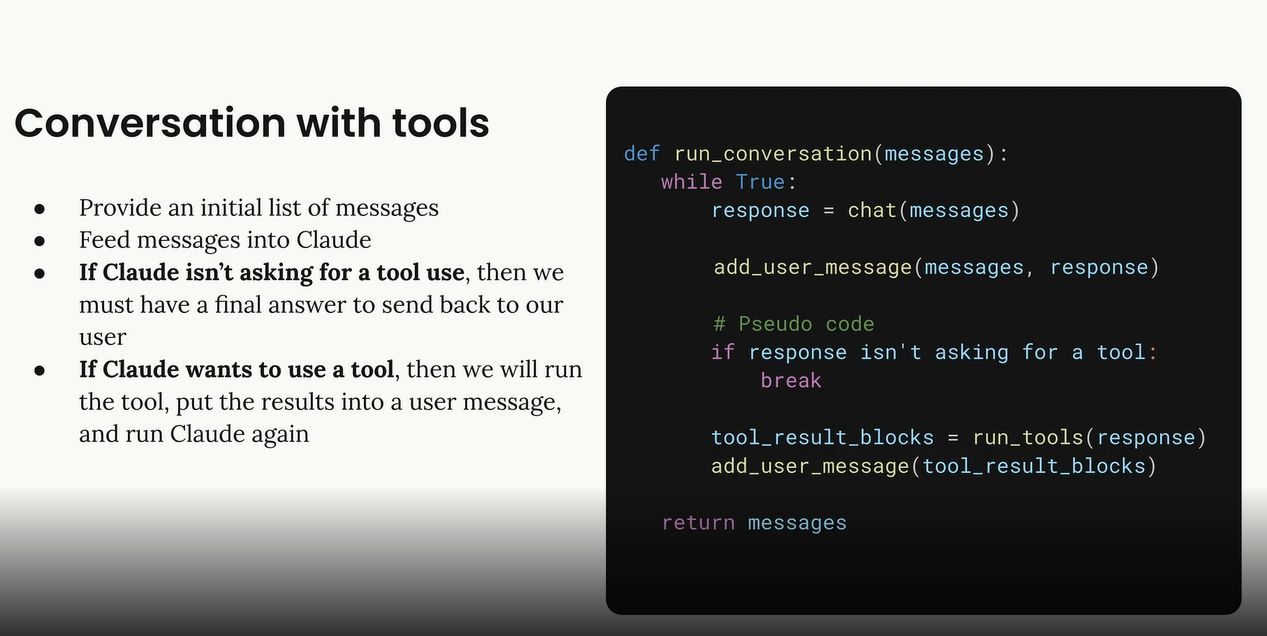



### Let's modify the helper functions to be more flexible

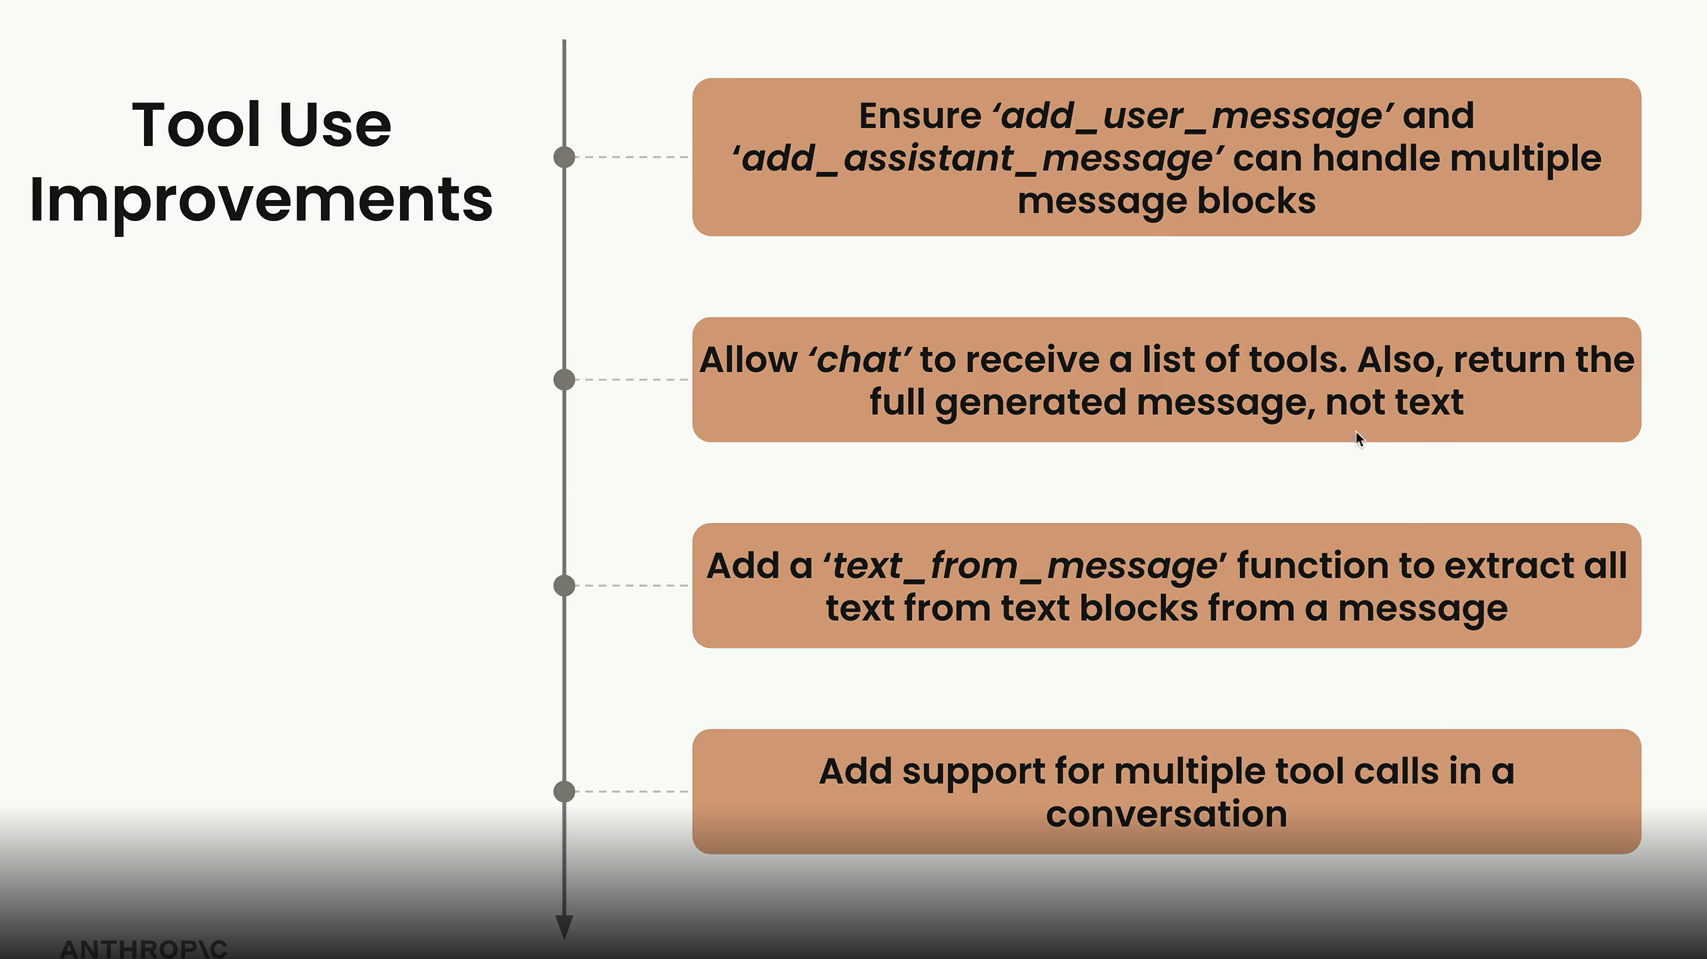

In [38]:
from anthropic.types import Message

# Helper functions
def add_user_message(messages, message):
    user_message = {
        "role": "user", 
        "content": message.content if isinstance(message,Message) else message
    }
    messages.append(user_message)


def add_assistant_message(messages, message):
    assistant_message = {
        "role": "assistant", 
        "content": message.content if isinstance(message,Message) else message
    }
    messages.append(assistant_message)

In [41]:
messages = []

add_user_message(messages,"What's the current time in HH:MM:SS format?")
response = client.messages.create(
    model = model,
    max_tokens=1000,
    messages=messages,
    tools = [get_current_datetime_schema]
)

add_assistant_message(messages,response)

In [42]:
messages

[{'role': 'user', 'content': "What's the current time in HH:MM:SS format?"},
 {'role': 'assistant',
  'content': [ToolUseBlock(id='toolu_018SizTKv7QEMQcgrYZN79of', caller=DirectCaller(type='direct'), input={'date_format': '%H:%M:%S'}, name='get_current_datetime', type='tool_use')]}]

In [45]:
def chat(messages, system=None, temperature=1.0, stop_sequences=[],tools=None):
    params = {
        "model": model,
        "max_tokens": 1000,
        "messages": messages,
        "temperature": temperature,
        "stop_sequences": stop_sequences,
    }

    if system:
        params["system"] = system

    if tools:
        params["tools"] = tools

    message = client.messages.create(**params)
    return message # Now it returns the whole Message object

def text_from_message(message):
    return "\n".join(
        [block.text for block in message.content if block.type == "text"]
    )

Message(id='msg_01BdgRHSYNnvMRXTJKAfU2W9', container=None, content=[TextBlock(citations=None, text="The exact time right now is 12:24:04 (HH:MM:SS format). Hope you're having a good day! 😊", **type='text'**)], model='claude-haiku-4-5-20251001', role='assistant', stop_details=None, stop_reason='end_turn', stop_sequence=None, type='message', usage=Usage(cache_creation=CacheCreation(ephemeral_1h_input_tokens=0, ephemeral_5m_input_tokens=0), cache_creation_input_tokens=0, cache_read_input_tokens=0, inference_geo='not_available', input_tokens=821, output_tokens=36, server_tool_use=None, service_tier='standard'))

### Implementing multiple turns (multiple tool calls)

Loop till Claude stops asking for a Tool use

`stop_reason` field Tells us why Claude stopped generating text:
* **"tool_use"**: Claude has decided that it needs to call a tool.
* **"end_turn"**: Claude has finished generating its assistant message.
* **"max_tokens"**: Claude has hit the token output limit and can't generate any more output.
* **"stop_sequence"**: Claude has encountered one of your provided stop sequences.

**OJO: There might be multiple `ToolUse` blocks in the same message (E.G. IF WE ASK CLAUDE TO ADD 10+10 AND 30+30 IN THE SAME MESSAGE)**

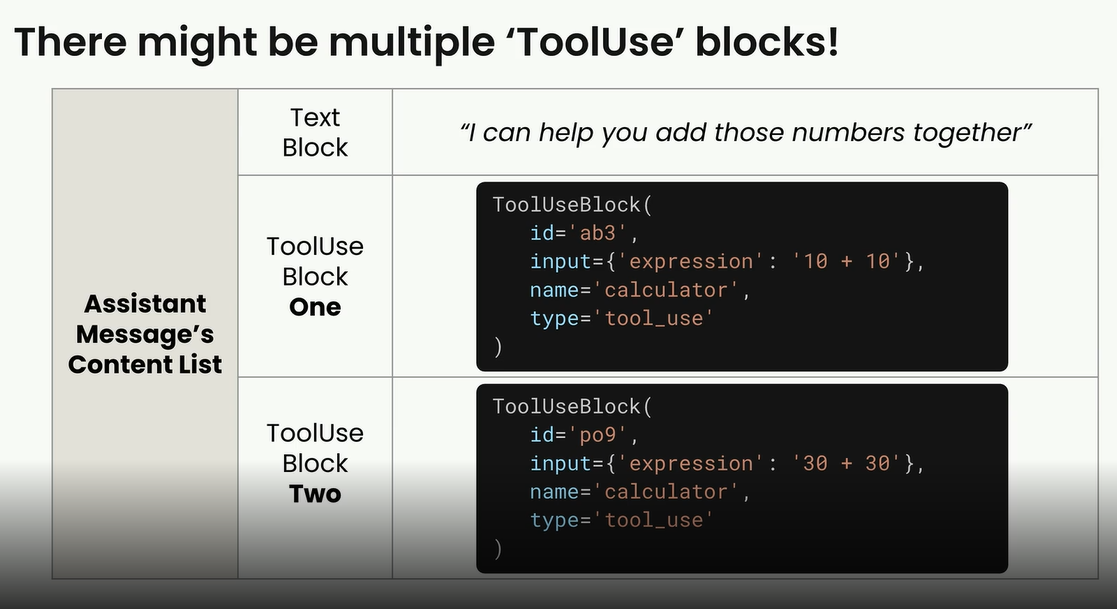

In [46]:
# ⭐✍️ Tricky! There might be multiple ToolUseBlock blocks
# We return ToolResultBlock(s)
import json

def run_tool(tool_name,tool_input):
    # Scales better, if we have another tool we can add elif statements here
    if tool_name == "get_current_datetime":
        return get_current_datetime(**tool_input)
    

def run_tools(message):
    tool_requests = [block for block in message.content if block.type == "tool_use"] # we only get the tool_use blocks

    tool_result_blocks = []

    for tool_request in tool_requests:

        try:
            tool_output = run_tool(tool_request.name,tool_request.input)
            tool_result_block = {
                "type":"tool_result",
                "tool_use_id" : tool_request.id,
                "content" : json.dumps(tool_output),
                "is_error": False
            }
        except Exception as e:
            tool_result_block = {
                "type":"tool_result",
                "tool_use_id" : tool_request.id,
                "content" : f"Error: {e}",
                "is_error": True
            }
        tool_result_blocks.append(tool_result_block)
    return tool_result_blocks

In [47]:
def run_conversation(messages):
    while True:
        response = chat(messages,tools=[get_current_datetime_schema])

        add_assistant_message(messages,response)
        print(text_from_message(response))

        if response.stop_reason != "tool_use":
            break
            
        # Claude wants to call a tool, we continue
        tool_results = run_tools(response)
        add_user_message(messages,tool_results)

    return messages

In [48]:
# Test: We'll send Claude a message that will require calling the get_current_datetime twice
messages = []
add_user_message(
    messages,
    "What's the current time in HH:MM format? Also, what is the current time in SS format?"
)
run_conversation(messages)


The current time is:
- **HH:MM format**: 12:59
- **SS format**: 50

So the current time is 12:59:50.


[{'role': 'user',
  'content': "What's the current time in HH:MM format? Also, what is the current time in SS format?"},
 {'role': 'assistant',
  'content': [ToolUseBlock(id='toolu_01NPyXTnKKqFVwz4A6L6JVmc', caller=DirectCaller(type='direct'), input={'date_format': '%H:%M'}, name='get_current_datetime', type='tool_use'),
   ToolUseBlock(id='toolu_01KtHvucAz9ma4zS3hPpELAp', caller=DirectCaller(type='direct'), input={'date_format': '%S'}, name='get_current_datetime', type='tool_use')]},
 {'role': 'user',
  'content': [{'type': 'tool_result',
    'tool_use_id': 'toolu_01NPyXTnKKqFVwz4A6L6JVmc',
    'content': '"12:59"',
    'is_error': False},
   {'type': 'tool_result',
    'tool_use_id': 'toolu_01KtHvucAz9ma4zS3hPpELAp',
    'content': '"50"',
    'is_error': False}]},
 {'role': 'assistant',
  'content': [TextBlock(citations=None, text='The current time is:\n- **HH:MM format**: 12:59\n- **SS format**: 50\n\nSo the current time is 12:59:50.', type='text')]}]

## Suport for multiple tools

We'll use 2 more tools:

* add duration to date time
* set reminder

In [56]:
# ⭐✍️ Tricky! There might be multiple ToolUseBlock blocks
# We return ToolResultBlock(s)
import json

def run_tool(tool_name,tool_input): # CHANGE: just add the tool names here
    # Scales better, if we have another tool we can add elif statements here
    if tool_name == "get_current_datetime":
        return get_current_datetime(**tool_input)
    elif tool_name == "add_duration_to_datetime":
        return add_duration_to_datetime(**tool_input)
    elif tool_name == "set_reminder":
        return set_reminder(**tool_input)

In [57]:
def run_conversation(messages):
    while True:
        response = chat(messages,tools=[get_current_datetime_schema, add_duration_to_datetime_schema, set_reminder_schema]) # CHANGE: add schemas here

        add_assistant_message(messages,response)
        print(text_from_message(response))

        if response.stop_reason != "tool_use":
            break
            
        # Claude wants to call a tool, we continue
        tool_results = run_tools(response)
        add_user_message(messages,tool_results)

    return messages

In [59]:
# Test: We'll send Claude a message that will require calling the get_current_datetime twice
messages = []
add_user_message(
    messages,
    "Set a reminder for my doctor's appointment. It's 177 days after Jan 1st, 2040 at 12:00"
)
run_conversation(messages)

I need to calculate the date that is 177 days after January 1st, 2040 at 12:00. Let me do that first.
Now I'll set the reminder for that date and time:
----
Setting the following reminder for 2040-06-26T12:00:00:
Doctor's appointment
----
Perfect! I've set a reminder for your doctor's appointment on **Tuesday, June 26, 2040 at 12:00 PM** (which is 177 days after January 1st, 2040 at 12:00). You'll receive a notification at that time.


[{'role': 'user',
  'content': "Set a reminder for my doctor's appointment. It's 177 days after Jan 1st, 2040 at 12:00"},
 {'role': 'assistant',
  'content': [TextBlock(citations=None, text='I need to calculate the date that is 177 days after January 1st, 2040 at 12:00. Let me do that first.', type='text'),
   ToolUseBlock(id='toolu_01VXzaQ19BPWD3t1k3gaHN2U', caller=DirectCaller(type='direct'), input={'datetime_str': '2040-01-01 12:00:00', 'input_format': '%Y-%m-%d %H:%M:%S', 'duration': 177, 'unit': 'days'}, name='add_duration_to_datetime', type='tool_use')]},
 {'role': 'user',
  'content': [{'type': 'tool_result',
    'tool_use_id': 'toolu_01VXzaQ19BPWD3t1k3gaHN2U',
    'content': '"Tuesday, June 26, 2040 12:00:00 PM"',
    'is_error': False}]},
 {'role': 'assistant',
  'content': [TextBlock(citations=None, text="Now I'll set the reminder for that date and time:", type='text'),
   ToolUseBlock(id='toolu_01AX9EMSQYGKd74jmgECJTnT', caller=DirectCaller(type='direct'), input={'content': 